# Code for Figure 5 Pre-training vs. Fine-tuning

Make sure to upload all the explanation_prompts jsons for every model at the same level as this notebook when running.

In [1]:
import json
import textwrap
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import re

Find important features:

In [2]:
# load and parse jsons
def load_json(file_path):
    with open(file_path, 'r') as file:
        return json.load(file)

# extract and process features from the JSON explanations
def process_features(data):
    results = {}
    all_features = []
    for layer, layer_data in data.items():
        sentences = layer_data['sentences'][0]
        numeric_features = [f for f in sentences if isinstance(f, list) and len(f) == 2 and isinstance(f[1], int)]
        positive = sorted(numeric_features, key=lambda x: x[1], reverse=True)[:5]
        negative = sorted(numeric_features, key=lambda x: x[1])[:5]
        results[layer] = {'positive': positive, 'negative': negative}
        all_features.extend(numeric_features)
    return results, all_features

#find overall top 10 features
def get_overall_top_features(all_features):
    feature_scores = defaultdict(int)
    for feature in all_features:
        feature_scores[feature[0]] += feature[1]
    sorted_features = sorted(feature_scores.items(), key=lambda x: x[1], reverse=True)
    return sorted_features[:10], sorted_features[-10:]

def analyze_models(files):
    all_results = {}
    for file_name in files:
        print(file_name)
        data = load_json(file_name)
        per_head_features, all_features = process_features(data)
        overall_top_positive, overall_top_negative = get_overall_top_features(all_features)
        all_results[file_name] = {
            'per_head': per_head_features,
            'overall_positive': overall_top_positive,
            'overall_negative': overall_top_negative,
        }
    return all_results

# JSON files to analyze
files = [
    'DNABERT_pretrained.json',
    'DNABERT_random_init.json',
    'DNABERT_random.json',
    'DNABERT.json',
    'enformer.json',
    'enformer_random_init.json',
    'scgpt_ms_pretrained.json',
    'scgpt_ms_random_init.json',
    'scgpt_ms.json', 'scgpt_pancreas_pretrained.json', 'scgpt_pancreas.json',
    'scgpt_pancreas_random_init.json'
]


model_results = analyze_models(files)

for model, features in model_results.items():
    print(f"Model: {model}")
    if(re.match("DNABERT",model)):
      total_heads = 144
    if (re.match("enformer", model)):
      total_heads = 88
    if (re.match("scgpt", model)):
      total_heads = 96
    print("Overall Top 10 Positive Features:", features['overall_positive'])
    print("Overall Top 10 Negative Features:", features['overall_negative'])
    print("\n")

DNABERT_pretrained.json
DNABERT_random_init.json
DNABERT_random.json
DNABERT.json
enformer.json
enformer_random_init.json
scgpt_ms_pretrained.json
scgpt_ms_random_init.json
scgpt_ms.json
scgpt_pancreas_pretrained.json
scgpt_pancreas.json
scgpt_pancreas_random_init.json
Model: DNABERT_pretrained.json
Overall Top 10 Positive Features: [('DM-type intertwined zinc finger factors', 298), ('Basic leucine zipper factors (bZIP)&SAND domain factors', 258), ('Nuclear receptors with C4 zinc fingers', 246), ('Basic leucine zipper factors (bZIP)', 226), ('Other C4 zinc finger-type factors&Basic helix-loop-helix factors (bHLH)', 180), ('repeat_DNA', 168), ('TEA domain factors', 140), ('Heteromeric CCAAT-binding factors', 120), ('Heat shock factors', 119), ('SAND domain factors', 116)]
Overall Top 10 Negative Features: [('Grainyhead domain factors', -99), ('T-Box factors', -99), ('Rel homology region (RHR) factors', -99), ('Basic helix-span-helix factors (bHSH)', -108), ('Tryptophan cluster factors',

Code for plotting:

In [3]:
import matplotlib.colors as mcolors

#wrap text to fit into the heatmap cells if plotting with text
def wrap_text(text, width=15):
    wrapped_text = text.replace('_', '\n')
    return '\n'.join(['\n'.join(textwrap.wrap(line, width)) for line in wrapped_text.split('\n')])

#features based on word
def process_features(data, word):
    word_features = defaultdict(list)
    cumulative_positive = 0
    cumulative_negative = 0
    total_heads = 0
    for layer, layer_data in data.items():
        sentences = layer_data['sentences'][0]
        for feature in sentences:
            if isinstance(feature, list) and len(feature) == 2 and isinstance(feature[1], (int, float)) and re.match(f".*{word}.*",feature[0]):
                word_features[layer].append(feature)
                if feature[1] > 0:
                    cumulative_positive += 1
                elif feature[1] < 0:
                    cumulative_negative += 1
        total_heads += len(layer_data['sentences'][0])
    return word_features, cumulative_positive, cumulative_negative, total_heads

#subplots
def create_subplot(features, title, word, num_layers, num_heads, split_term):
    data = np.zeros((num_layers, num_heads))
    annotations = np.full((num_layers, num_heads), '', dtype=object)

    for layer, items in features.items():
        layer_idx = int(layer.split('layer')[1].split(split_term)[0])
        head_idx = int(layer.split('head')[1])
        for feature in items:
            data[layer_idx, head_idx] = feature[1]
            annotations[layer_idx, head_idx] = wrap_text(feature[0], width=10)

    return data, annotations

def analyze_and_visualize_models(files, word):
    all_data = []
    results = []
    all_annotations = []
    for file_name in files:
        data = load_json(file_name)
        word_features, cum_positive, cum_negative, total_heads = process_features(data, word)
        normalized_positive = (cum_positive / total_heads) * 100
        normalized_negative = (cum_negative / total_heads) * 100
        if re.match('scgpt.*', file_name):
          num_heads = 8
          num_layers = 12
          split_term = "_"
          figure_size = (50,10)
        if re.match('enformer.*', file_name):
           num_heads = 8
           num_layers = 11
           split_term = "-"
           figure_size = (50, 10)
        if re.match('DNABERT.*', file_name):
           num_heads = 12
           num_layers = 12
           split_term = "-"
           figure_size=(50, 10)
        data, annotations = create_subplot(word_features, file_name, word, num_layers, num_heads,split_term)
        all_data.append(data)
        all_annotations.append(annotations)
        results.append((normalized_positive, normalized_negative))

    global_min = min(data.min() for data in all_data)
    global_max = max(data.max() for data in all_data)

    fig, axs = plt.subplots(1, len(files), figsize=figure_size)
    for idx, (data, annot, result) in enumerate(zip(all_data, all_annotations, results)):
        file_name = files[idx]
         # Define a diverging colormap with grey at zero
        norm = mcolors.TwoSlopeNorm(vmin=global_min, vcenter=0, vmax=global_max)
        sns.heatmap(data, ax=axs[idx], cmap='coolwarm', cbar=True, norm=norm, fmt="", vmin=global_min, vmax=global_max)
        #code to annotate feature names on the squares in heatmap
        #sns.heatmap(data, ax=axs[idx], annot = annot, cmap='coolwarm', cbar=True, fmt="", vmin=global_min, vmax=global_max)
        axs[idx].set_title(f'{file_name.split("/")[-1]} - "{word}"\nNorm Pos: {result[0]:.2f}, Norm Neg: {result[1]:.2f}')
        axs[idx].set_xlabel('Head Index')
        axs[idx].set_ylabel('Layer Index')


    plt.tight_layout()
    plt.show()


Figure 5 for scGPT models:

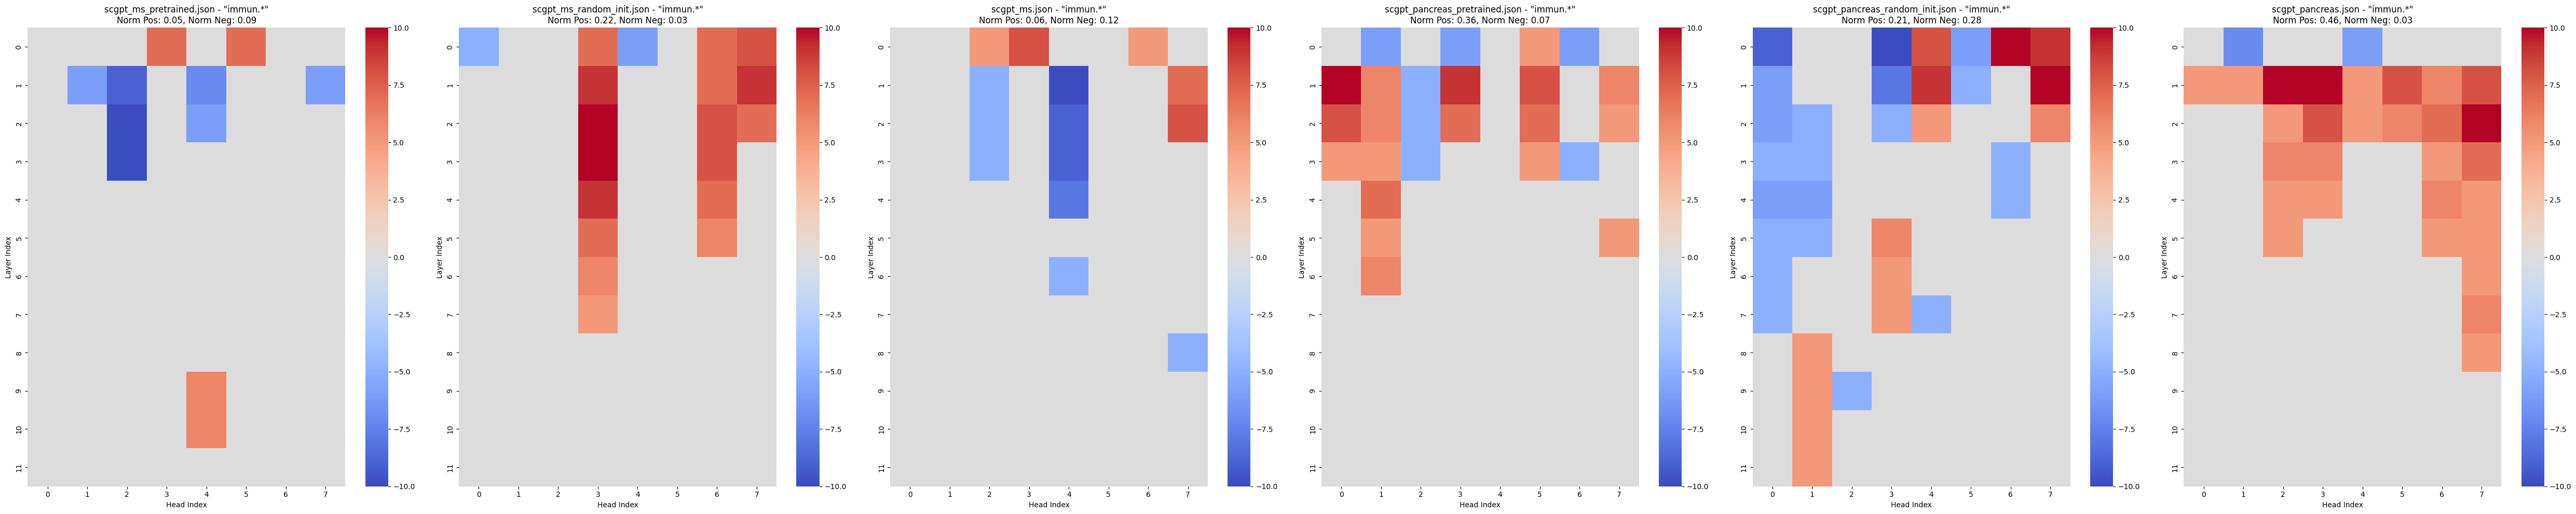

In [4]:
files = [
    'scgpt_ms_pretrained.json',
    'scgpt_ms_random_init.json',
    'scgpt_ms.json', 'scgpt_pancreas_pretrained.json', 'scgpt_pancreas_random_init.json','scgpt_pancreas.json'
]
#for figure = pancreas
feature_word = 'immun.*'
analyze_and_visualize_models(files, feature_word)


For DNABERT and enformer models:

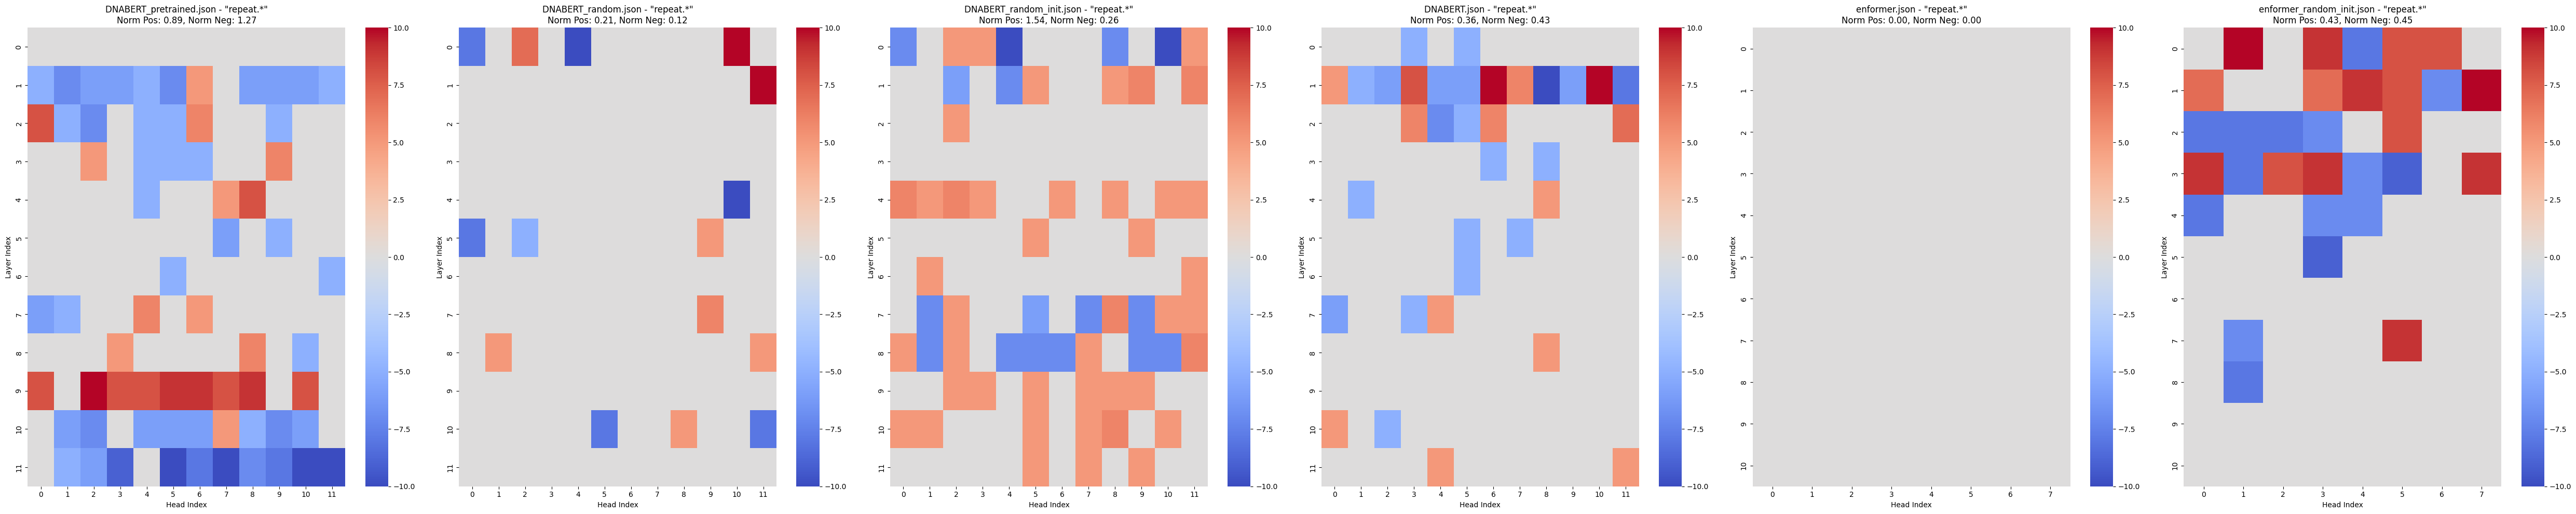

In [7]:
files = [
    'DNABERT_pretrained.json',
    'DNABERT_random.json',
    'DNABERT_random_init.json',
    'DNABERT.json',
    'enformer.json',
    'enformer_random_init.json'
]

# for figure:
feature_word = 'repeat.*'
analyze_and_visualize_models(files, feature_word)